In [1]:
import os
import sys
import warnings

warnings.filterwarnings('ignore')

import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import get_linear_schedule_with_warmup
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments  

import random
from tqdm import tqdm
import gc


def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
set_seed(42)

-------
## 1. Смотрим на данные

In [3]:
df = pd.read_csv("data.csv", sep=';')
df.shape

(1763, 2)

In [4]:
df.head()

,text,class
0,Невнимательность к покупателю. Товар выносят п...,Товар
1,Посудомоечная машина не исправна. Остальной то...,Товар
2,"Приехал в магазин, оказался только Витринный о...",Товар
3,Несколько раз переносили дату доставки.,Доставка
4,"На сайте было написано бесплатная доставка,а п...",Доставка


<Axes: title={'center': 'Распределение классов'}, xlabel='class'>

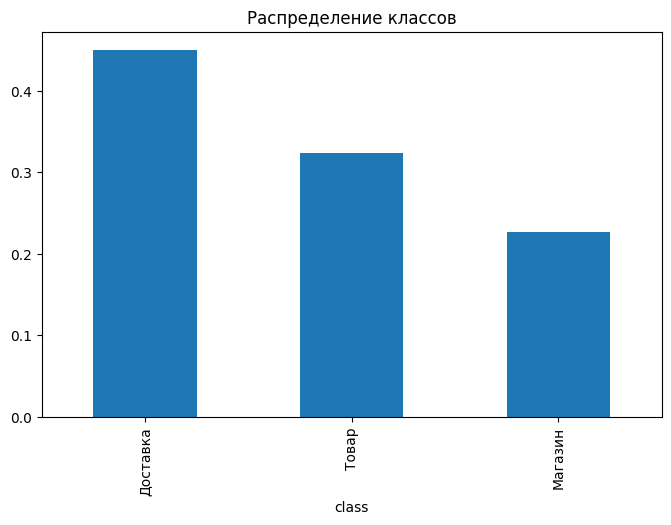

In [5]:
df['class'].value_counts(normalize=True).plot(kind='bar', title='Распределение классов', figsize=(8, 5),)

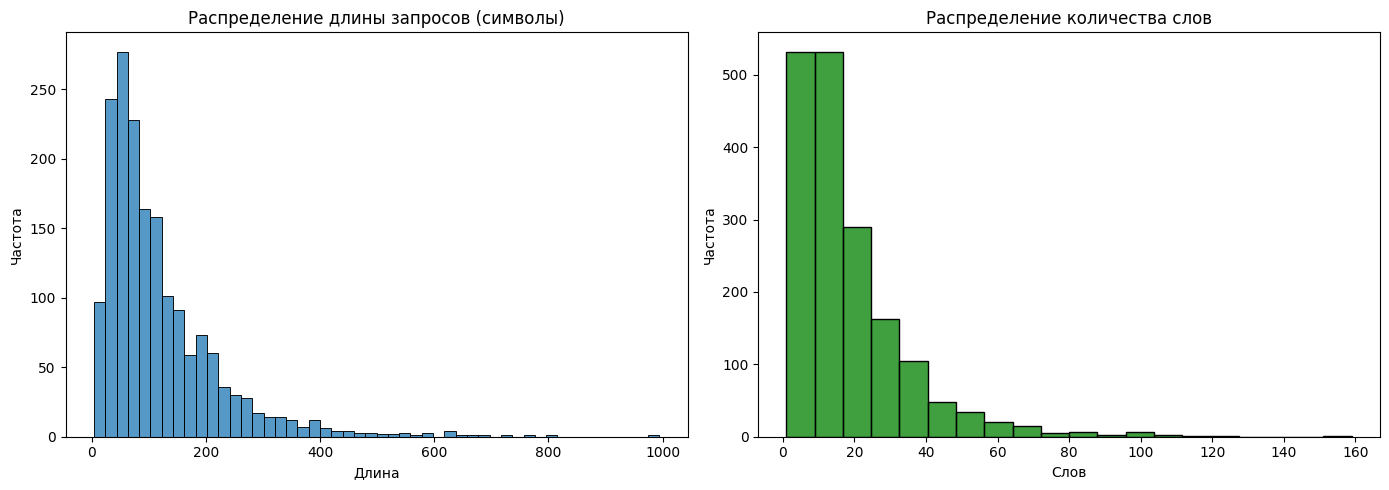

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Длина в символах
sns.histplot(df['text'].str.len(), bins=50, ax=axes[0])
axes[0].set_title('Распределение длины запросов (символы)')
axes[0].set_xlabel('Длина')
axes[0].set_ylabel('Частота')

# Количество слов
df['word_count'] = df['text'].str.split().str.len()
sns.histplot(df['word_count'], bins=20, ax=axes[1], color='g')
axes[1].set_title('Распределение количества слов')
axes[1].set_xlabel('Слов')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

3 класса, распределение даже более менее сбалансированное (лучше чем в большинстве случаев)
-----
--------

Предобработка текста (лемматизация и удаление не информативных частей) для TF-IDF и тому подобного
------

In [7]:
from natasha import (
    Segmenter,
    MorphVocab,
    NewsEmbedding,
    NewsMorphTagger,
    Doc
)

segmenter = Segmenter()
morph_vocab = MorphVocab()
emb = NewsEmbedding()
morph_tagger = NewsMorphTagger(emb)

# Чести речи, которые мы игнорим
IGNORED_POS = {'PUNCT', 'CCONJ', 'SCONJ', 'PART', 'PRON', 'ADP', 'DET'}

# Не информативные слова (для BM25)
STOP_WORDS = {'быть', 'это', 'который', 'свой', 'наш', 'ваш'}

def preprocess_text(text):
        
    cleaned_text = text.replace("_x000D_", "").strip()
    
    doc = Doc(cleaned_text)
    doc.segment(segmenter) # токенизируем
    doc.tag_morph(morph_tagger) # тэгаем морфемы

    lemmatized_words = []
    for token in doc.tokens:
        token.lemmatize(morph_vocab)
        
        # Проверяем на вход
        if token.pos not in IGNORED_POS and token.lemma not in STOP_WORDS:
            lemmatized_words.append(token.lemma)
            
    return " ".join(lemmatized_words)

df['text_preprocessed'] = df['text'].apply(preprocess_text)


In [8]:
from collections import Counter


def top_words_analysis(df, class_label, n=10):
    texts = df['text_preprocessed'].fillna('').astype(str)[df['class']==class_label]

    all_words = []
    for text in texts:
        words = text.split()
        all_words.extend(words)

    total_words = len(all_words)
    unique_words = len(set(all_words))


    print(f"Всего слов в корпусе: {total_words}")
    print(f"Уникальных слов: {unique_words}")
    print(f"Средняя длина одного отзыва: {round(total_words / len(texts), 1)}\n")

    word_counts = Counter(all_words)

    print("Топ частых слов:")
    print(f"{'Слово':<20} | {'Частота':<10} | {'Доля':<10}")
    print("-" * 45)

    for word, count in word_counts.most_common(n):
        percentage = (count / total_words) * 100
        print(f"{word:<20} | {count:<10} | {percentage:.2f}%")

for i in df['class'].unique():
    print(f"\nКласс: {i}")
    top_words_analysis(df, i, n=5)



Класс: Товар
Всего слов в корпусе: 5628
Уникальных слов: 1781
Средняя длина одного отзыва: 9.9

Топ частых слов:
Слово                | Частота    | Доля      
---------------------------------------------
товар                | 246        | 4.37%
витринный            | 93         | 1.65%
магазин              | 77         | 1.37%
образец              | 73         | 1.30%
заказ                | 68         | 1.21%

Класс: Доставка
Всего слов в корпусе: 10326
Уникальных слов: 1971
Средняя длина одного отзыва: 13.0

Топ частых слов:
Слово                | Частота    | Доля      
---------------------------------------------
доставка             | 500        | 4.84%
заказ                | 426        | 4.13%
товар                | 217        | 2.10%
курьер               | 192        | 1.86%
день                 | 176        | 1.70%

Класс: Магазин
Всего слов в корпусе: 5063
Уникальных слов: 1612
Средняя длина одного отзыва: 12.7

Топ частых слов:
Слово                | Частота    | Доля    

Чуток визуализации
-----

In [9]:
from bm25_vectorizer import BM25Vectorizer

# BM25 потому что TF-IDF круто, а это еще круче
corpus = df['text_preprocessed'].tolist()
vec = BM25Vectorizer(transformer="bm25plus").fit(corpus)

vectors = vec.transform(corpus)

In [10]:
from sklearn.decomposition import TruncatedSVD, KernelPCA
from sklearn.manifold import TSNE

# Явно инициализируем через PCA (хотя в sklearn TSNE сам использует init PCA, но чет мне нравиться как он работает)
vectors_pca = KernelPCA(n_components=100, kernel='linear', random_state=42).fit_transform(vectors.toarray())
tsne = TSNE(n_components=2, 
            random_state=42, 
            verbose=1, 
            perplexity=15)

tsne_vectors = tsne.fit_transform(vectors_pca)

[t-SNE] Computing 46 nearest neighbors...
[t-SNE] Indexed 1763 samples in 0.001s...
[t-SNE] Computed neighbors for 1763 samples in 0.068s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1763
[t-SNE] Computed conditional probabilities for sample 1763 / 1763
[t-SNE] Mean sigma: 3.919801
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.347351
[t-SNE] KL divergence after 1000 iterations: 1.449054


<Axes: >

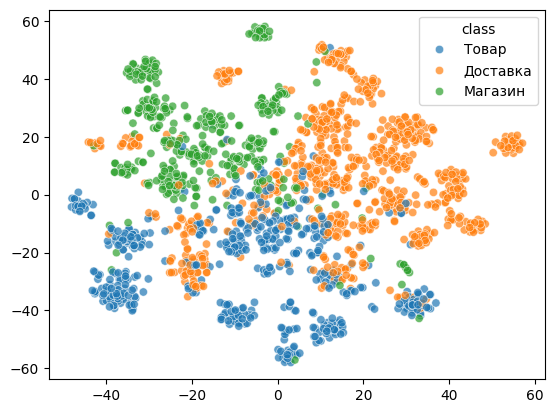

In [11]:
sns.scatterplot(x=tsne_vectors[:, 0], y=tsne_vectors[:, 1], hue=df['class'], alpha=0.7)

Даже по визуализации, можно сделать вывод что задача довольно тривиальна
----
---------

Обычный split с стратификацией для баланса классов
-----

In [12]:
train, val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['class'])

Опять BM25 
---

In [13]:
from bm25_vectorizer import BM25Vectorizer

train_corpus_preprocessed = train['text_preprocessed'].tolist()
val_corpus_preprocessed = val['text_preprocessed'].tolist()
vec = BM25Vectorizer(transformer="bm25plus").fit(train_corpus_preprocessed)

train_vectors_preprocessed = vec.transform(train_corpus_preprocessed)
val_vectors_preprocessed = vec.transform(val_corpus_preprocessed)

In [14]:
from sklearn.linear_model import LogisticRegression 

model = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

model.fit(train_vectors_preprocessed, train['class'])

val_predictions = model.predict(val_vectors_preprocessed)
val['predicted_class'] = val_predictions
print(classification_report(val['class'], val_predictions))

              precision    recall  f1-score   support

    Доставка       0.91      0.95      0.93       159
     Магазин       0.97      0.91      0.94        80
       Товар       0.90      0.89      0.89       114

    accuracy                           0.92       353
   macro avg       0.93      0.92      0.92       353
weighted avg       0.92      0.92      0.92       353



В принципе, уже линейка справляетья неплохо с f1-macro 0.92, по метрикам видно, что "Товар" проседает относительно других
----

In [15]:
val[val['class'] != val_predictions][['text', 'class', 'predicted_class']].sample(7).style.set_properties(**{
    'text-align': 'left',
    'white-space': 'normal',
    'border': '1px solid #ccc',
    'padding': '10px'
}) # Только щас узнал что можно так делать

,text,class,predicted_class
595,"Однако, продавцы нынче совсем обнаглели! Интернет заказ был оформлен, от продавца требовалось показать внешний вид товара. Продавец, не услышав моей просьбы, предложил оплатить товар. Я попросил повторно, на что мне сказали вначале оплата, тогда уже пришлось настойчивее общаться. А дальше ""потрясающий"" вопрос, заданный продавцом, оказался показательным к отношению данного работника к клиентам и своей трудовой деятельности, а также обязанностям. Спросил: ""И че вы хотите там увидеть"". Дальше открыл коробку и молча ждёт: ""ну типа че встал, дальше давай сам.""_x000D_",Товар,Магазин
1552,"Доставка очень огорчила, в процессе транспортировки было испорчено мое имущество - поцарапана стена и глубокая царапина на стиральной машинке.",Доставка,Товар
457,"На вопрос проверки внешнего вида и комплектации ответили, - нам некогда бросили мне чек и ушли.",Доставка,Товар
539,"поступил в ужасном виде, в рваной упаковке.Отрицательное впечатление.Ужасное отношение к своим клиентам, которые осуществляют заказ посредством экспресс доставки",Товар,Доставка
79,"Отвратительно. Заказал, оплатил, простоял в очереди полтора часа чтобы узнать что некомплект",Товар,Магазин
84,"Ужасная доставка. Принес товар, начал психовать, что его нужно проверять на целостность.Показывал всем своим видом, что нужно ему уже срочно бежать.Доставка оставляет желать лучшего, желание покупать что-либо после такого отпадает.",Доставка,Товар
886,"Когда я стал проверять на столе свой товар, подошёл другой покупатель с менеджером и они просто вытеснили меня со стола, распаковав там пылесос со всеми насадками, шлангом и прочей фигнёй. Если бы сотрудник убрал со стола непонятные коробки, которые там лежали, то места хватило бы всем. Но ему оказалось проще выжать клиента",Магазин,Товар


Как будто примеры на которых моделька ошиблась довольно шумные, для сэмпла 1562 вообще разметка подвела (как мне кажется)
-----
-------

Ради интереса catboost
----

In [16]:
from catboost import CatBoostClassifier
from catboost import Pool

train_pool = Pool(data=train['text_preprocessed'].to_frame(), label=train['class'], text_features=['text_preprocessed'])
val_pool = Pool(data=val['text_preprocessed'].to_frame(), label=val['class'], text_features=['text_preprocessed'])

model = CatBoostClassifier(iterations=1000, 
                           learning_rate=0.1, 
                           depth=4, 
                           verbose=100,
                           eval_metric='TotalF1:average=Macro', # в тз не сказано какой именно f1, поэтому будем считать что macro
                           loss_function='MultiClass')

model.fit(train_pool, eval_set=val_pool, early_stopping_rounds=50)

0:	learn: 0.8874998	test: 0.8742635	best: 0.8742635 (0)	total: 90.5ms	remaining: 1m 30s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9057053588
bestIteration = 11

Shrink model to first 12 iterations.


CatBoostClassifier(depth=4, eval_metric='TotalF1:average=Macro', iterations=1000, learning_rate=0.1, loss_function='MultiClass', verbose=100)

In [17]:
val_predictions = model.predict(val_pool)
print(classification_report(val['class'], val_predictions))

              precision    recall  f1-score   support

    Доставка       0.93      0.95      0.94       159
     Магазин       0.94      0.84      0.89        80
       Товар       0.87      0.91      0.89       114

    accuracy                           0.91       353
   macro avg       0.91      0.90      0.91       353
weighted avg       0.91      0.91      0.91       353



Чуток хуже линейки
----

----------
Нейросетевые эксперименты (в runtime нам это не надо запускать я думаю, так что по latency каких-то особых ограничений я не вижу смысла соблюдать)
-----

In [ ]:
class ReviewDataset(Dataset): # наш датасет
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

        self.target_mapping = {label: idx for idx, label in enumerate(sorted(set(labels)))}

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.target_mapping[self.labels[idx]]
        
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

Свой Trainer
----

In [24]:
from sklearn.model_selection import StratifiedKFold

class ReviewTrainer:
    def __init__(self, model, train_loader, val_loader, criterion,
                 device, epochs=5, lr=2e-5, warmup_ratio=0.1, 
                 patience=3, label_names=None, 
                 use_wandb=False, fold_num=None):
        
        self.model = model.to(device)
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.criterion = criterion
        self.device = device
        
        self.epochs = epochs
        self.lr = lr
        self.warmup_ratio = warmup_ratio
        self.patience = patience

        self.label_names = label_names
        self.use_wandb = use_wandb
        self.fold_num = fold_num
        
        self.best_f1 = 0.0
        self.patience_counter = 0
        self.global_step = 0

    def _get_optimizer_and_scheduler(self):
        optimizer = AdamW(self.model.parameters(), lr=self.lr)
        total_steps = len(self.train_loader) * self.epochs
        warmup_steps = int(total_steps * self.warmup_ratio)
        scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
        return optimizer, scheduler

    def _train_epoch(self, optimizer, scheduler, criterion):
        self.model.train()
        total_loss = 0
        
        pbar = tqdm(self.train_loader, desc=f"Fold {self.fold_num} Training", leave=False)
        for batch in pbar:
            input_ids = batch['input_ids'].to(self.device)
            attention_mask = batch['attention_mask'].to(self.device)
            labels = batch['labels'].to(self.device)
            
            optimizer.zero_grad()
            outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)['logits']

            loss, dice_loss, ce_loss = criterion(outputs, labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.5)
            
            optimizer.step()
            scheduler.step()
            
            total_loss += loss.item()
            self.global_step += 1
            
            # Логируем шаг в W&B
            if self.use_wandb:
                wandb.log({
                    "step_loss": loss.item(), 
                    "ce_loss": ce_loss.item(),
                    "dice_loss": dice_loss.item(),
                    "lr": scheduler.get_last_lr()[0],
                    "global_step": self.global_step
                })
                
            pbar.set_postfix({'loss': f"{loss.item():.4f}"})
            
        return total_loss / len(self.train_loader)

    def _evaluate(self):
        self.model.eval()
        all_preds, all_labels = [], []
        
        with torch.no_grad():
            for batch in tqdm(self.val_loader, desc="Evaluating", leave=False):
                input_ids = batch['input_ids'].to(self.device)
                attention_mask = batch['attention_mask'].to(self.device)
                labels = batch['labels'].to(self.device)
                
                outputs = self.model(input_ids=input_ids, attention_mask=attention_mask)
                preds = torch.argmax(outputs.logits, dim=1)
                
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
                
        f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
        return f1_macro, all_preds, all_labels

    def fit(self, save_dir="./best_model"):
        optimizer, scheduler = self._get_optimizer_and_scheduler()
        criterion = self.criterion
        os.makedirs(save_dir, exist_ok=True)
        
        for epoch in range(self.epochs):
            train_loss = self._train_epoch(optimizer, scheduler, criterion)
            val_f1, _, _ = self._evaluate()
            
            print(f"Epoch {epoch+1}/{self.epochs} | Loss: {train_loss:.4f} | Val F1-macro: {val_f1:.4f}")
            
            # Логируем эпоху в W&B
            if self.use_wandb:
                wandb.log({
                    "epoch_train_loss": train_loss, 
                    "epoch_val_f1": val_f1,
                    "epoch": epoch + 1
                })
            
            if val_f1 > self.best_f1:
                self.best_f1 = val_f1
                self.patience_counter = 0
                self.model.save_pretrained(save_dir, verbose=False)
                print(f"лучшая модель (F1: {val_f1:.4f}) в {save_dir}")
            else:
                self.patience_counter += 1
                if self.patience_counter >= self.patience:
                    print("Early stopping!")
                    break
                    
        print(f"\nBest F1-macro: {self.best_f1:.4f}")
        return self.best_f1

    def final_report(self):
        _, y_true, y_pred = self._evaluate()
        print("\n" + "="*40)
        print(classification_report(y_true, y_pred, target_names=self.label_names))



In [20]:
import wandb # Не забудь сделать wandb login в терминале перед запуском!
API_KEY = os.getenv("WANDB_API_KEY")
wandb.login(key=API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/egor/.netrc
wandb: Currently logged in as: proninegor (proninegor-financial-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

Dice для оптимизации под f1
-----

In [21]:
class MulticlassDiceLoss(nn.Module):
    def __init__(self, smooth=1e-5):
        super(MulticlassDiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)
        
        targets = targets
        
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        
        intersection = (probs * targets_one_hot).sum(dim=0)
        union = probs.sum(dim=0) + targets_one_hot.sum(dim=0)
        
        dice_per_class = (2.0 * intersection + self.smooth) / (union + self.smooth)
        return 1.0 - dice_per_class.mean()


    
class DiceCELoss(nn.Module):
    def __init__(
        self,
        smooth = 0.05,
        label_smoothing = 0.05,
        ce_weight = 0.5,
        dice_weight = 0.5):

        super(DiceCELoss, self).__init__()
        
        self.dice = MulticlassDiceLoss(smooth=smooth)
        
        self.ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
        self.ce_weight = ce_weight
        self.dice_weight = dice_weight

    def forward(self, inputs, target):

        dice_loss = self.dice(inputs, target)
        ce_loss = self.ce(inputs.view(-1, inputs.size(-1)), target.view(-1)) 
        
        loss = self.dice_weight * dice_loss + self.ce_weight * ce_loss
        return loss, dice_loss, ce_loss

Kfold train (выборка небольшая, так что можно сделать)
-----

In [25]:
def kfold_training(df, model_name, n_splits=5, batch_size=16, max_length=256, use_wandb=True):
    if torch.cuda.is_available():
        device = 'cuda'
    elif torch.backends.mps.is_available():
        device = 'mps' # я на маке сидел с M2
    else:
        device = 'cpu'

    device = torch.device(device)

    tokenizer = AutoTokenizer.from_pretrained(model_name)
    
    folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    fold_metrics = []
    
    # конфиг для WB
    wandb_config = {
        "model_name": model_name,
        "n_splits": n_splits,
        "batch_size": batch_size,
        "max_length": max_length,
        "epochs": 25,
        "lr": 2e-5,
        "label_smoothing": 0.05
    }

    for fold, (train_idx, val_idx) in enumerate(folds.split(df, df['class'])):
        print(f"\n FOLD {fold + 1} / {n_splits}")
        
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)
        
        train_texts = train_df['text'].tolist() 
        val_texts = val_df['text'].tolist()
        
        train_dataset = ReviewDataset(train_texts, train_df['class'].tolist(), tokenizer, max_length)
        val_dataset = ReviewDataset(val_texts, val_df['class'].tolist(), tokenizer, max_length)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)

        criterion = DiceCELoss(smooth = 0.05,
            label_smoothing = wandb_config["label_smoothing"],
            ce_weight = 0.5,
            dice_weight = 0.5)
        
        
        if use_wandb:
            wandb.init(
                project="mv-review-classification", 
                name=f"rubert-tiny2-fold-{fold+1}",
                config=wandb_config,
                reinit=True
            )
        model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)
        
        save_dir = f"./models/kfold/fold_{fold+1}"
        
        trainer = ReviewTrainer(
            model=model, 
            train_loader=train_loader, 
            val_loader=val_loader, 
            criterion=criterion,
            device=device,
            label_names=['Доставка', 'Магазин', 'Товар'],
            use_wandb=use_wandb,
            epochs=wandb_config["epochs"],
            lr=wandb_config["lr"],
            warmup_ratio=0.1,
            patience=5,
            fold_num=fold + 1
        )
        
        best_f1 = trainer.fit(save_dir=save_dir)
        fold_metrics.append(best_f1)
        
        if use_wandb:
            wandb.finish() 
            
        del model, trainer, train_loader, val_loader
        gc.collect() # Чичтим кэши
        torch.cuda.empty_cache()

    for i, metric in enumerate(fold_metrics):
        print(f"Fold {i+1} F1-macro: {metric:.4f}")

    print("-" * 40)
    print(f"Mean F1-macro: {np.mean(fold_metrics):.4f}")
    
    return fold_metrics

In [ ]:
if __name__ == "__main__":
    MODEL_NAME = "cointegrated/rubert-tiny2" # rubert-tiny2 для легких экспериментов (у меня лучше всех завелась)
    
    fold_results = kfold_training(
        df=df, 
        model_name=MODEL_NAME, 
        n_splits=5, 
        batch_size=32, 
        max_length=256, 
        use_wandb=True # делать логи wb или нет
    )


 FOLD 1 / 5


Loading weights:   0%|          | 0/55 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
              

Epoch 1/25 | Loss: 0.8908 | Val F1-macro: 0.3490


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

лучшая модель (F1: 0.9399) в ./models/kfold/fold_3


Epoch 14/25 | Loss: 0.1196 | Val F1-macro: 0.9368


Epoch 15/25 | Loss: 0.1190 | Val F1-macro: 0.9399


Epoch 16/25 | Loss: 0.1147 | Val F1-macro: 0.9348


Fold 3 Training:  93%|█████████▎| 42/45 [00:33<00:03,  1.07s/it, loss=0.1104]

Переобучаем моделку на всех данных
-----

In [ ]:
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps' # я на маке сидел с M2
else:
    device = 'cpu'

device = torch.device(device)

tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2")
final_model = AutoModelForSequenceClassification.from_pretrained("cointegrated/rubert-tiny2", num_labels=3)

full_train_dataset = ReviewDataset(df['text'].tolist(), df['class'].tolist(), tokenizer, max_length=256)
full_train_loader = DataLoader(full_train_dataset, batch_size=32, shuffle=True)

final_criterion = DiceCELoss(smooth=0.05, label_smoothing=0.05, ce_weight=0.5, dice_weight=0.5)

final_trainer = ReviewTrainer(
    model=final_model,
    train_loader=full_train_loader,
    val_loader=None, # Val-а нету 
    criterion=final_criterion,
    device=device,
    epochs=25,
    lr=2e-5,
    warmup_ratio=0.1,
    patience=10,
    use_wandb=False,
    fold_num="Full"
)

final_trainer.fit(save_dir="./final_model")